# Stage 5A: diagnose PCB2 before changing the detector

This is post-confirmation development diagnosis. Stage4 was committed/pushed as
2ec21c4; its original predictions, code and model banks remain unchanged. This
notebook reads saved diagnostic tables, figures and receipts. It performs no raw
image access, feature extraction, fitting, scoring, threshold tuning or networking.

The strongest first intervention candidate is canonical orientation normalization,
not yet tested. Reversed boards have broad maps, but do not explain image-level
misses here. Canonical missing-label misses retrieve local references, weakening
the proposed distant-match explanation. Read these as associations, not causes.

In [1]:
from pathlib import Path
import hashlib,json,io
import pandas as pd
from PIL import Image as PILImage
from IPython.display import display,Image,Markdown
root=Path.cwd()
if not (root/'artifacts').is_dir():root=root.parent
base=root/'artifacts/stage5a'
def sha(p):return hashlib.sha256(p.read_bytes()).hexdigest()
def table(name):return pd.read_csv(base/name)
def show(name):
    with PILImage.open(base/name) as im:
        im.thumbnail((1000,1800));buf=io.BytesIO();im.save(buf,format='PNG')
    display(Image(data=buf.getvalue()))
metadata=json.loads((base/'report_metadata.json').read_text())
assert metadata['new_detector_inference'] is False
for field in ['sources','outputs']:
    for name,expected in metadata[field].items():
        assert sha(root/name)==expected,name
review=json.loads((base/'independent_review.json').read_text())
assert review['passed']
frame=table('combined/per_image_diagnostics.csv')
assert len(frame)==200 and frame.image_id.is_unique
assert frame.missing_component.sum()==19
print('Verified saved report identities and diagnostic grain.')

Verified saved report identities and diagnostic grain.


## Pose: compare anomalies with anomalies

The image-only pin classifier labeled1,101 images before outcome joins. All1,001
normals are canonical. Among100 anomalies,90 canonical,5 reversed,5 uncertain.
Uncertain images visually have canonical layouts with damaged connector cues;
do not combine them with reversed poses. PriorStage4 knowledge exists, so this
is not retrospectively double-blind. No reversed normals means no reversed FPR.
The main FP comparison uses90/5/5 anomalies, not pooled canonical normals.

,split,normal_or_anomaly,pose_label,count
0,anomaly_test,anomaly,canonical,90
1,anomaly_test,anomaly,reversed_180,5
2,anomaly_test,anomaly,uncertain,5
3,calibration,normal,canonical,181
4,fit,normal,canonical,720
5,normal_test,normal,canonical,100


,recipe,pose_label,normal_or_anomaly,n_images,median_fp_pixels,q25_fp_pixels,q75_fp_pixels,total_fp_pixels
0,d1,canonical,anomaly,90,2639.5,1551.50,3735.50,248353
1,d1,canonical,normal,100,527.0,299.50,1015.25,81281
2,d1,reversed_180,anomaly,5,29180.0,28440.00,29697.00,146977
3,d1,uncertain,anomaly,5,5912.0,5094.00,6831.00,33725
4,d2,canonical,anomaly,90,1577.5,1083.50,2156.25,149832
5,d2,canonical,normal,100,585.0,396.75,884.75,65668
6,d2,reversed_180,anomaly,5,19367.0,19104.00,19627.00,97150
7,d2,uncertain,anomaly,5,2650.0,1940.00,3045.00,12943


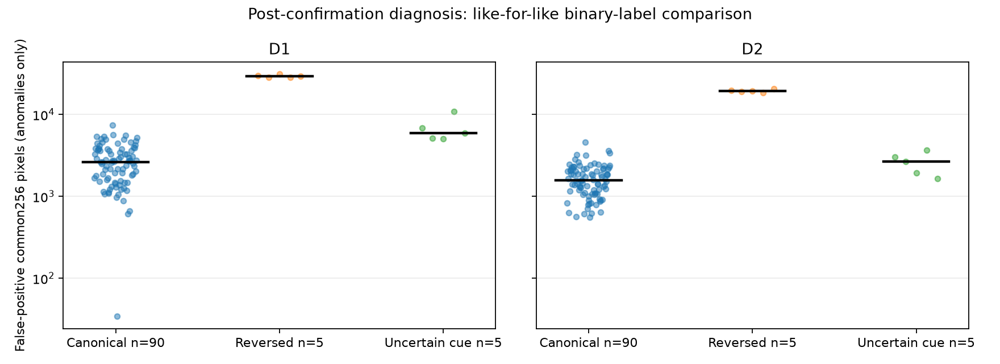

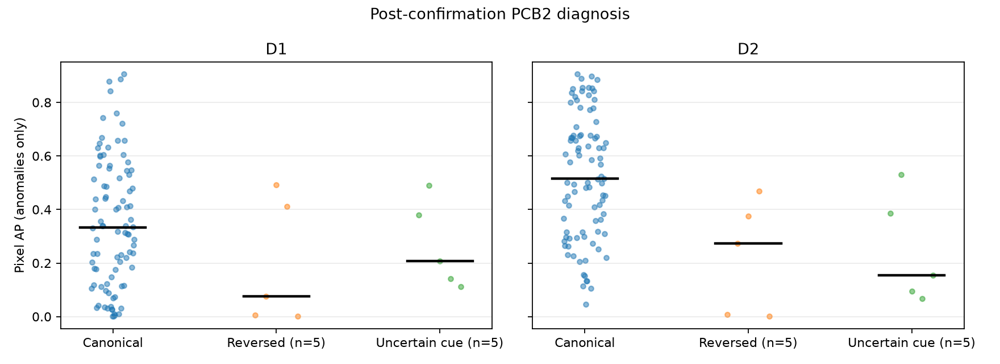

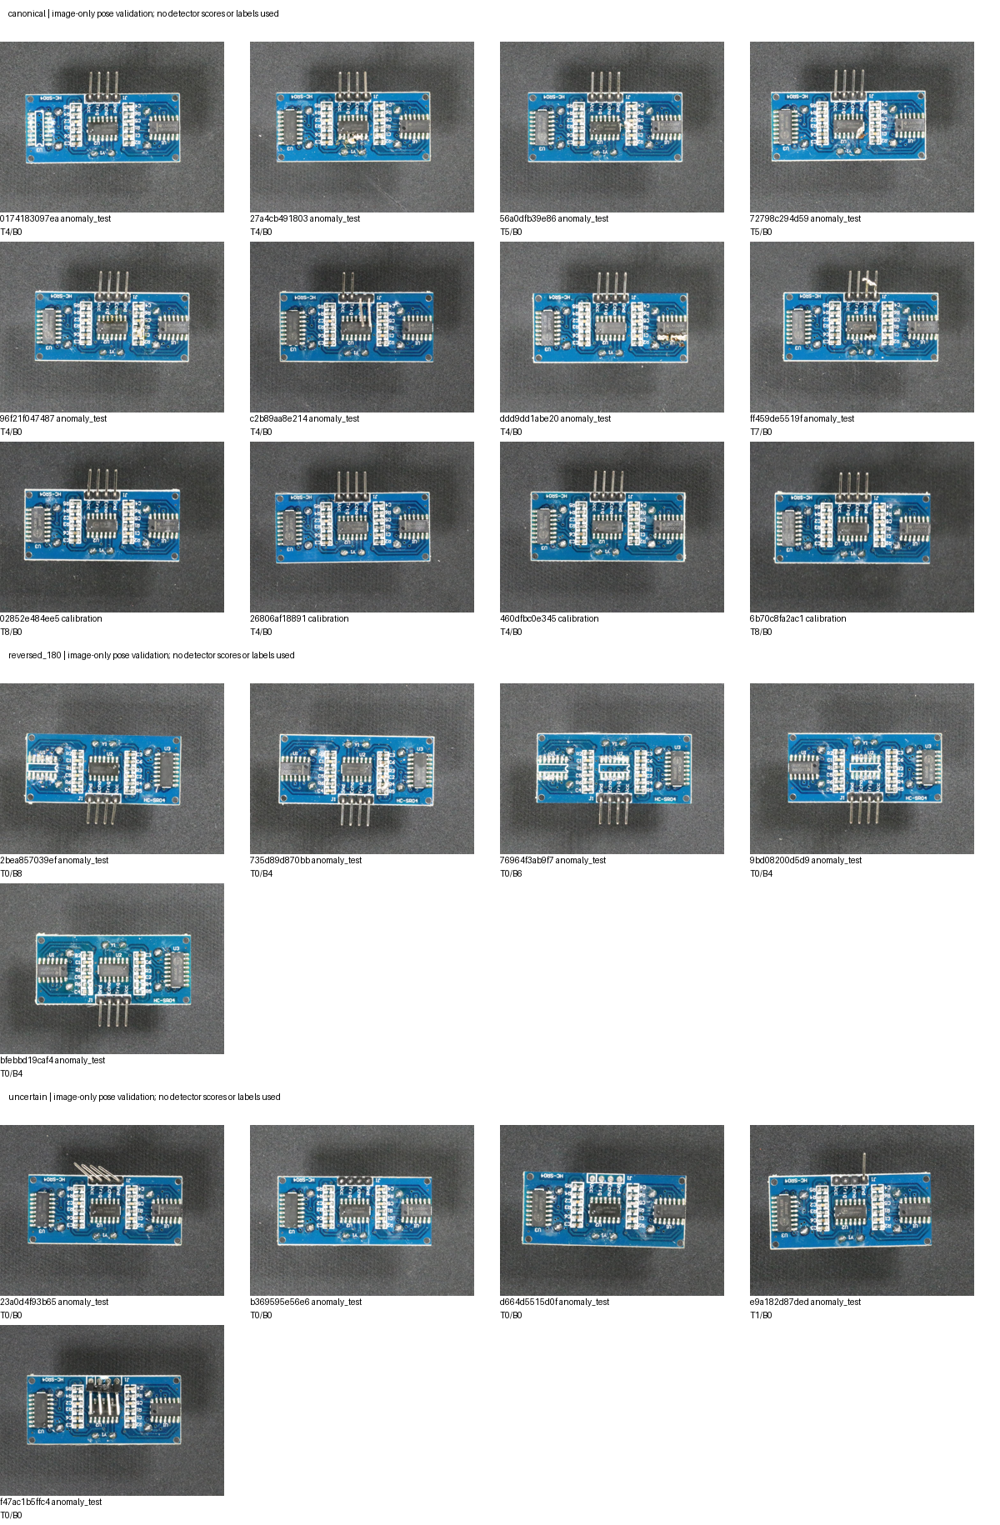

In [2]:
display(table('pose/pose_population.csv'))
display(table('pose/pose_binary_stratified_summary.csv').round(4))
show('pose/pose_fp_pixels_anomalies.png')
show('pose/pose_pixel_ap.png')
show('pose/pose_contact_sheet.png')

## Missing labels: frozen top-five references

All19 missing-labeled cases, both resolutions, all mask-overlap grid footprints
and a one-cell context ring were traced:3,698 queries/18,490 pairs. No spatial
restriction was applied. Radii0.05/0.10/0.20 are crop-diagonal units, not tuned.
Union GT on two multi-type images cannot isolate a particular missing component;
grid-cell footprints are not the full ResNet receptive field. Image-weighted
summaries avoid letting larger defects contribute more rows to group medians.
The30-pair bounded center-context visual review is not a prevalence estimate.

,image_id,pose_label,outcome_group,d1_pixel_ap,d2_pixel_ap,d1_nn_spatial_median,d2_nn_spatial_median
0,0174183097ea8fa63bbe3153,canonical,M3 both hit,0.8780,0.8884,0.0222,0.0311
1,2744e38a1b628fcbf2067bd4,canonical,M3 both hit,0.1474,0.1133,0.0447,0.0729
2,2bea857039ef9c03907fb299,reversed_180,M3 both hit,0.4918,0.3756,0.0877,0.2484
3,31656a11b9780d9f8a2fa83f,canonical,M3 both hit,0.5650,0.8435,0.0221,0.0174
4,733208e2c25e1af5454d93f2,canonical,M1 both miss,0.0098,0.0463,0.0018,0.0195
5,76964f3ab9f7c03b08de6900,reversed_180,M3 both hit,0.4121,0.4694,0.0739,0.2253
6,846cfdd3fbe431251239629c,canonical,M3 both hit,0.8431,0.8558,0.0271,0.0221
7,86317f47cc684a4a33717793,canonical,M1 both miss,0.0010,0.1512,0.0221,0.0312
8,8a393ef07e4999ab89669d93,canonical,M2 D2 rescue,0.0369,0.3163,0.0026,0.0175
9,9bd08200d5d939f4a498aae7,reversed_180,M3 both hit,0.0757,0.2739,0.0937,0.1093


,size,query_set,pose_label,outcome_group,n_images,median_distance,median_displacement,median_cross_location_fraction
5,256,defect_overlap,canonical,M1 both miss,6,1.4719,0.0090,0.0000
6,256,defect_overlap,canonical,M2 D2 rescue,1,1.4540,0.0026,0.0000
7,256,defect_overlap,canonical,M3 both hit,5,1.8192,0.0228,0.0028
8,256,defect_overlap,reversed_180,M3 both hit,4,2.3228,0.0907,0.4438
9,256,defect_overlap,uncertain,M3 both hit,3,1.6462,0.1106,0.5207
15,512,defect_overlap,canonical,M1 both miss,6,1.9026,0.0253,0.0919
16,512,defect_overlap,canonical,M2 D2 rescue,1,2.0220,0.0175,0.1054
17,512,defect_overlap,canonical,M3 both hit,5,2.2679,0.0311,0.2600
18,512,defect_overlap,reversed_180,M3 both hit,4,2.4635,0.1673,0.6167
19,512,defect_overlap,uncertain,M3 both hit,3,1.7065,0.1327,0.5682


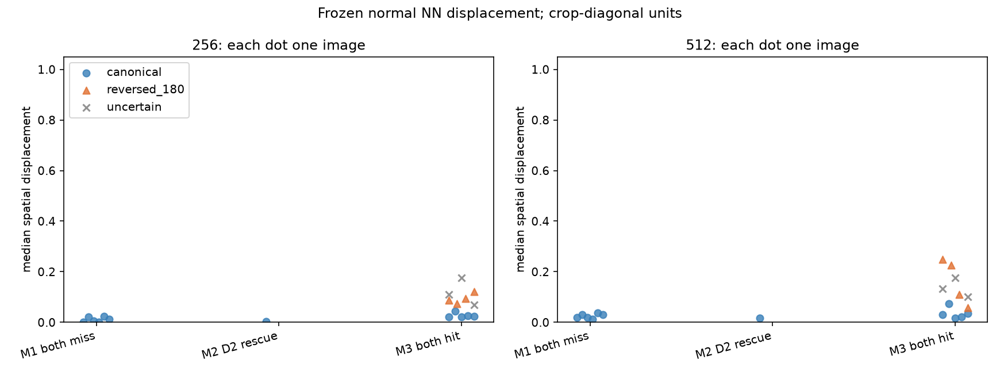

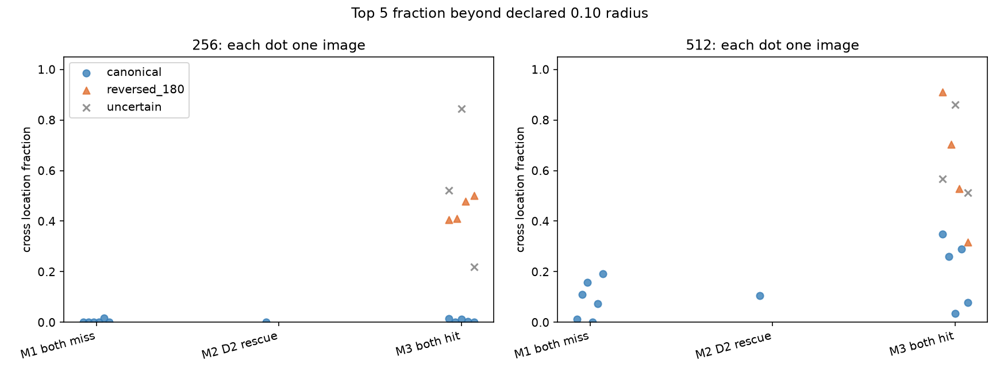

,query_image_id,size,neighbor_rank,context_label,review_status
0,0174183097ea8fa63bbe3153,256,1,component,visually_reviewed_conservative
1,0174183097ea8fa63bbe3153,256,2,component,visually_reviewed_conservative
2,0174183097ea8fa63bbe3153,256,3,uncertain,visually_reviewed_conservative
3,0174183097ea8fa63bbe3153,256,4,uncertain,visually_reviewed_conservative
4,0174183097ea8fa63bbe3153,256,5,uncertain,visually_reviewed_conservative
5,0174183097ea8fa63bbe3153,512,1,uncertain,visually_reviewed_conservative
6,0174183097ea8fa63bbe3153,512,2,uncertain,visually_reviewed_conservative
7,0174183097ea8fa63bbe3153,512,3,empty_board,visually_reviewed_conservative
8,0174183097ea8fa63bbe3153,512,4,empty_board,visually_reviewed_conservative
9,0174183097ea8fa63bbe3153,512,5,empty_board,visually_reviewed_conservative


In [3]:
cases=table('missing_component/missing_cases.csv')
trace=table('missing_component/nn_trace.csv')
assert len(cases)==19 and len(trace)==18490
assert trace.groupby(['query_image_id','size','query_id']).size().eq(5).all()
display(cases[['image_id','pose_label','outcome_group','d1_pixel_ap','d2_pixel_ap','d1_nn_spatial_median','d2_nn_spatial_median']].round(4))
display(table('missing_component/group_summary.csv').query("query_set=='defect_overlap'").round(4))
show('missing_component/missing_hit_vs_miss.png')
show('missing_component/cross_location_fraction.png')
display(table('missing_component/selected_reference_context_review.csv')[['query_image_id','size','neighbor_rank','context_label','review_status']])

## Broad maps and small defects

The4×4 grid is normalized crop content with letterbox padding excluded. Conservative
crop background remains; cells are not registered anatomical zones. Common256
counts and native-content spread have different explicit denominators. Fixed color
scales permit within-recipe panel comparisons. Pixel evidence, patch-max image
flags and competing responses are kept separate. Operational small-defect categories
can overlap and do not prove representation failure. D2 differs in normal calibration
and candidate population as well as resolution.

,recipe,normal_or_anomaly,pose_label,count,median_map_spread,median_fp_pixels,total_fp_pixels,median_pixel_ap
0,D1,anomaly,canonical,90,0.0699,2639.5,248353,0.3329
1,D1,anomaly,reversed_180,5,0.7465,29180.0,146977,0.0757
2,D1,anomaly,uncertain,5,0.1422,5912.0,33725,0.2085
3,D1,normal,canonical,100,0.0134,527.0,81281,NaN
4,D2,anomaly,canonical,90,0.0436,1577.5,149832,0.5148
5,D2,anomaly,reversed_180,5,0.5020,19367.0,97150,0.2739
6,D2,anomaly,uncertain,5,0.0772,2650.0,12943,0.1549
7,D2,normal,canonical,100,0.0148,585.0,65668,NaN


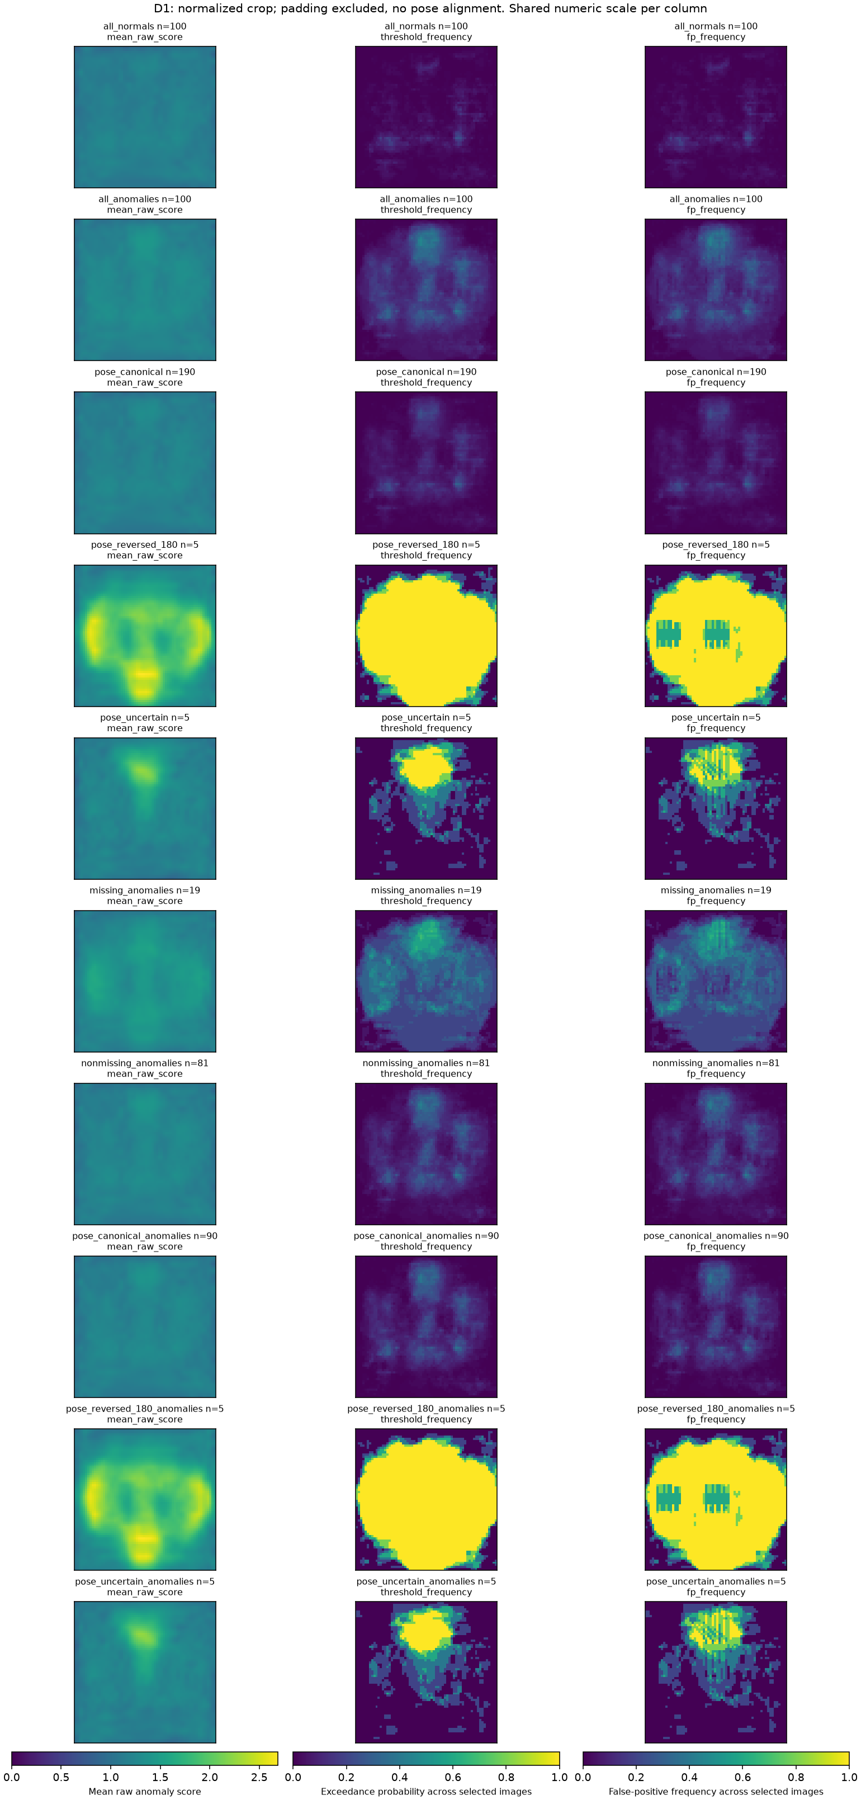

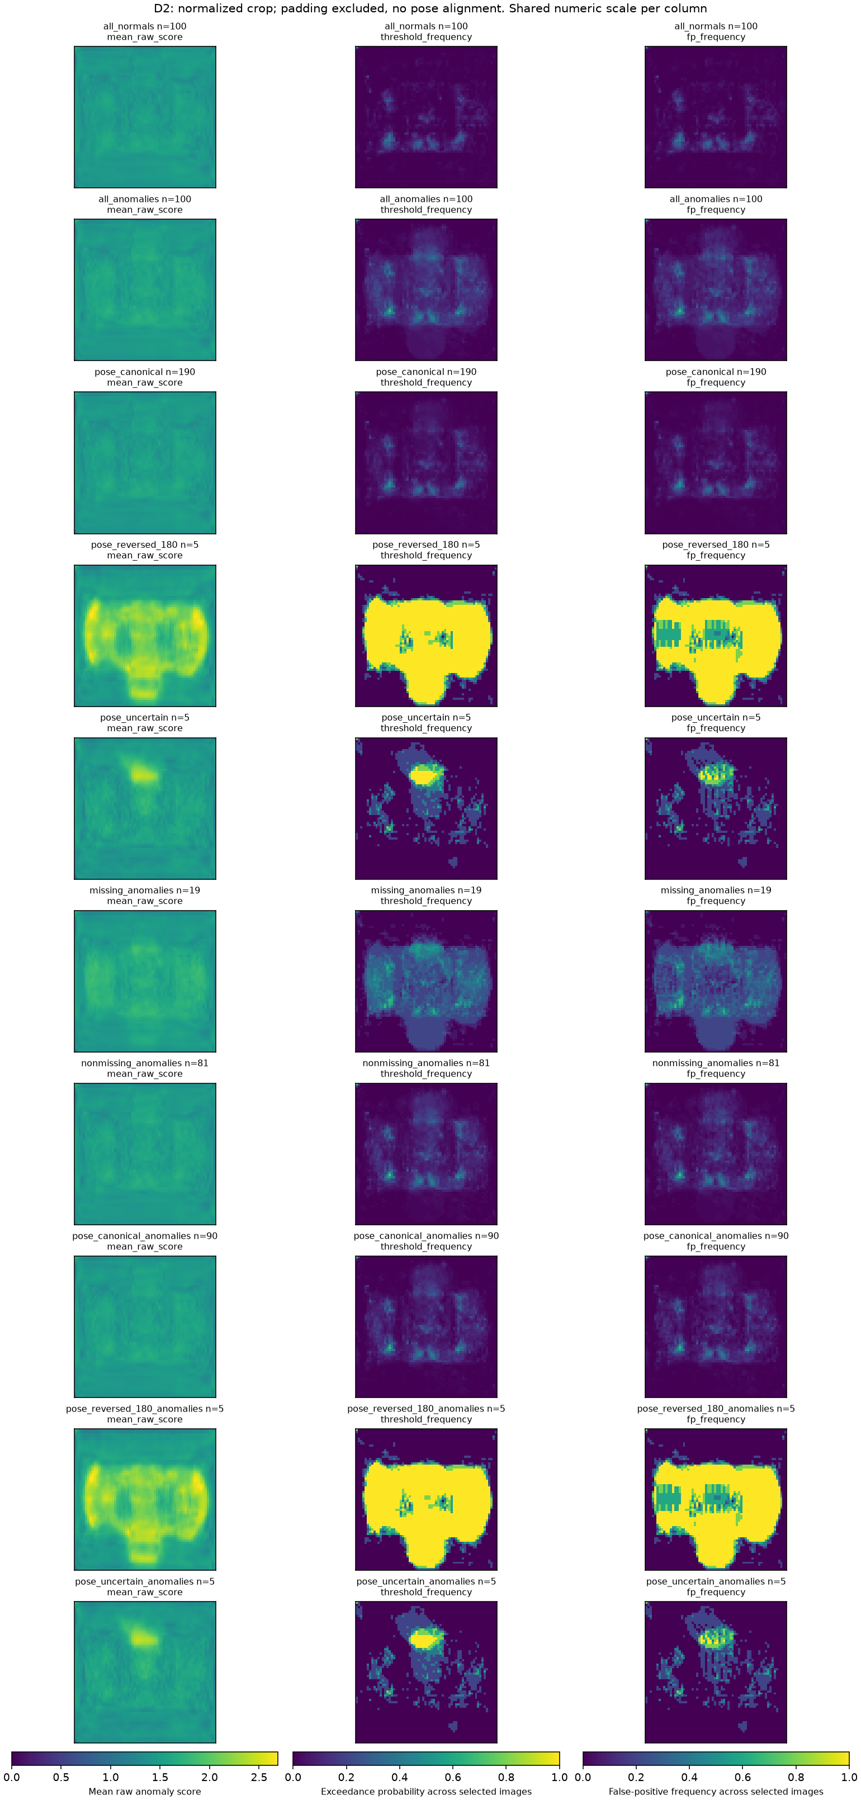

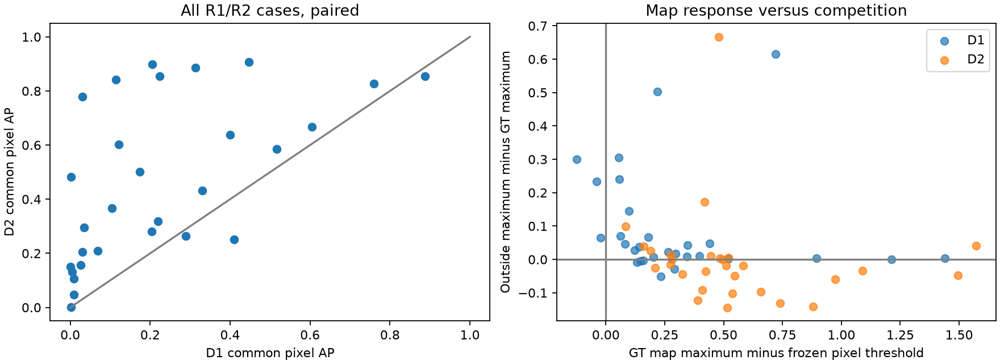

In [4]:
maps=table('broad_maps/map_spread.csv')
assert maps.groupby('recipe').size().eq(200).all()
assert int(maps.query("recipe=='D1'").common_fp_pixels.sum())==510336
assert int(maps.query("recipe=='D2'").common_fp_pixels.sum())==325593
display(table('combined/pose_x_map_spread.csv').round(4))
show('broad_maps/D1_aggregate_maps.png')
show('broad_maps/D2_aggregate_maps.png')
small=table('small_defects/failure_decomposition.csv')
assert len(small)==58 and small.image_id.nunique()==29
show('small_defects/small_case_decomposition.png')

## Combined confounders and one future decision

Every missing-label miss is canonical. Six missing-labeled small cases are difficult
for both recipes compared with nonmissing cases in the same coarse size bands;
exact size, source labels and context remain confounded. Reversed anomalies explain
a substantial FP burden but only five images are available. Canonical orientation
normalization is one proposed controlledStage5B test; it has not been executed,
and it is not expected automatically to resolve canonical missing-label misses.

In [5]:
display(table('combined/pose_x_missing.csv').round(4))
display(table('combined/size_x_missing.csv').round(4))
display(Markdown((base/'combined/decision_summary.md').read_text()))
display(pd.DataFrame(review['saved_map_independent_counts']))
print('Stage4 identity comparisons:',review['stage4_identity_checks'])
print('Query/reference coordinate checks:',review['query_reference_coordinate_checks'])
print('Independent sampled distance checks:',review['subset_distance_checks'])
print('All saved maps reconciled; frozen native trace maps matched exactly.')

,recipe,pose_label,missing_detected,count,median_pixel_ap,median_fp_pixels,nn_median_distance,nn_spatial_median,cross_location_r010
0,D1,canonical,False,7,0.0264,1423.0,1.4540,0.0049,0.0000
1,D1,canonical,True,5,0.5650,2725.0,1.8192,0.0228,0.0028
2,D1,reversed_180,False,0,NaN,NaN,NaN,NaN,NaN
3,D1,reversed_180,True,4,0.2439,28810.0,2.3228,0.0907,0.4438
4,D1,uncertain,False,0,NaN,NaN,NaN,NaN,NaN
5,D1,uncertain,True,3,0.1408,5912.0,1.6462,0.1106,0.5207
6,D2,canonical,False,6,0.1823,801.0,1.9026,0.0253,0.0919
7,D2,canonical,True,6,0.5799,1961.5,2.1450,0.0266,0.1827
8,D2,reversed_180,False,0,NaN,NaN,NaN,NaN,NaN
9,D2,reversed_180,True,4,0.3248,19235.5,2.4635,0.1673,0.6167


,recipe,size_band,missing_component,count,detected,recall,median_mask_area_pixels,median_pixel_ap
0,D1,R1,False,10,6,0.6000,84.0,0.1901
1,D1,R1,True,4,1,0.2500,52.5,0.0019
2,D1,R2,False,13,8,0.6154,111.0,0.2890
3,D1,R2,True,2,0,0.0000,108.0,0.0183
4,D1,R3,False,33,29,0.8788,170.0,0.3392
5,D1,R3,True,1,0,0.0000,150.0,0.0264
6,D1,R4,False,25,25,1.0000,260.0,0.4791
7,D1,R4,True,12,11,0.9167,716.0,0.1779
8,D2,R1,False,10,8,0.8000,84.0,0.4339
9,D2,R1,True,4,1,0.2500,52.5,0.1799


# Stage 5A decision: test orientation normalization first

**One proposed Stage 5B intervention:** image-only canonical orientation normalization before existing D1 feature extraction. Not executed.

Five reversed anomalies account for 28.80%/29.84% of all false-positive pixels; anomaly-only median burden is 11.1×/12.3× canonical anomalies and crop spread is 0.7465/0.5020 vs 0.0699/0.0436. Both recipes show the direction. All reversed cases are detected; no reversed normals exists, so pose is a candidate mechanism for broad maps, not an explanation for image misses or causal proof.

Missing-label misses occur on canonical boards and retrieve more local references than matched canonical hits. This weakens spatial restrictions as the first intervention. Six both-missed cases remain unresolved, and only one missing-label case is rescued by D2. Size and source labels remain confounded.

Control the future experiment: current D1 vs D1 plus orientation normalization, image-only pose rule/uncertain handling declared before results; unchanged layers, memory budget/selection, scoring and calibration policy; measure canonical/reversed localization and overall detection/resources. Do not combine with another intervention. New PCB2 results are post-confirmation development.

See the complete method/evidence/limits in `docs/journey/stage_05a_failure_diagnosis.md` and combined tables here. No Stage 5B detector was fitted or scored.


,recipe,independent_saved_map_count_images,fp_pixels,intersection_pixels,union_pixels
0,D1,200,510336,25495,537415
1,D2,200,325593,24841,352672


Stage4 identity comparisons: 1514
Query/reference coordinate checks: 36980
Independent sampled distance checks: 190
All saved maps reconciled; frozen native trace maps matched exactly.


## Verification scope and preserved history

The independent review rechecked all200 diagnostic IDs/flags/scores/pixel AP values,
full common-map FP/intersection/union counts, exact frozen reference indices and
all saved coordinate conversions. Float64 feature distances were checked on190
fixed query subsets; there was no second independent full feature extraction.
Manual center-view contexts include uncertainty; no anatomical causal claim is made.
Earlier preparation-clock and transport caveats remain in the Stage4 history.
The readable journey chapter and final diagnostic receipt link the exact evidence.
No detector parameter or Stage5B model was changed or evaluated.